In [79]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# ---------------------------- 1. 数据预处理 ----------------------------
def load_battery_mat(file_path):
    """加载 NASA 电池数据文件"""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"文件不存在: {file_path}")

    file_size = os.path.getsize(file_path)
    if file_size < 1024 * 100:
        raise ValueError(f"文件 {file_path} 大小异常 ({file_size} 字节)，可能下载不完整")

    try:
        mat = loadmat(file_path)
    except Exception as e:
        raise ValueError(f"无法读取 {file_path}，请确认文件是有效的 MATLAB v5 .mat 格式。错误详情: {e}")

    battery_keys = [key for key in mat.keys() if key.startswith('B') and not key.startswith('__')]
    if not battery_keys:
        raise ValueError(f"文件中未找到以 'B' 开头的电池变量")
    battery_key = battery_keys[0]
    battery_struct = mat[battery_key][0, 0]

    cycles_field = battery_struct['cycle']
    cycles = np.squeeze(cycles_field)
    if cycles.ndim == 0:
        cycles = np.array([cycles])

    data_list = []

    for i in range(cycles.shape[0]):
        cycle = cycles[i]

        cycle_type = cycle['type'].item() if cycle['type'].size == 1 else cycle['type'][0]
        ambient_temp = cycle['ambient_temperature'].item() if cycle['ambient_temperature'].size == 1 else cycle['ambient_temperature'][0, 0]
        time = cycle['time'].item() if cycle['time'].size == 1 else cycle['time'][0, 0]

        data_field = cycle['data']
        if data_field.size == 0:
            continue

        if cycle_type == 'discharge':
            voltage = data_field['Voltage_measured'][0, 0].flatten()
            current = data_field['Current_measured'][0, 0].flatten()
            temp = data_field['Temperature_measured'][0, 0].flatten()
            capacity = data_field['Capacity'][0, 0].item()

            try:
                impedance = data_field['Impedance'][0, 0].item()
            except (KeyError, IndexError, ValueError):
                impedance = np.nan

            data_list.append({
                'cycle': i,
                'type': cycle_type,
                'ambient_temp': ambient_temp,
                'time': time,
                'capacity': capacity,
                'impedance': impedance,
                'voltage': voltage,
                'current': current,
                'temperature': temp
            })

    df = pd.DataFrame(data_list)
    return df

def extract_ic_features(voltage_series, capacity_series, v_min=3.2, v_max=4.2):
    """提取 IC 曲线峰值特征"""
    v = np.array(voltage_series)
    cap = np.array(capacity_series)

    mask = (v >= v_min) & (v <= v_max)
    v = v[mask]
    cap = cap[mask]

    if len(v) < 2:
        return np.nan, np.nan

    sort_idx = np.argsort(v)
    v = v[sort_idx]
    cap = cap[sort_idx]

    dq = np.diff(cap)
    dv = np.diff(v)
    with np.errstate(divide='ignore', invalid='ignore'):
        ic = dq / dv
    ic = np.nan_to_num(ic, nan=0.0, posinf=0.0, neginf=0.0)

    ic_smooth = gaussian_filter1d(ic, sigma=1)

    peak_idx = np.argmax(ic_smooth)
    peak_v = v[peak_idx] if peak_idx < len(v) else np.nan
    peak_val = ic_smooth[peak_idx]

    return peak_v, peak_val

def prepare_battery_data(file_paths, save_path='battery_data.npz', capacity_threshold=0.8, window_size=30):
    """处理电池文件，生成训练/测试集，RUL 基于容量阈值计算"""
    all_cycles = []
    battery_initial_cap = {}

    for fp in file_paths:
        print(f"处理文件: {fp}")
        df = load_battery_mat(fp)
        battery_id = os.path.basename(fp).split('.')[0]

        first_cap = df.iloc[0]['capacity']
        battery_initial_cap[battery_id] = first_cap

        for _, row in df.iterrows():
            v_seq = row['voltage']
            cap_total = row['capacity']
            if len(v_seq) > 0:
                cap_seq = np.linspace(0, cap_total, len(v_seq))
                peak_v, peak_val = extract_ic_features(v_seq, cap_seq)
            else:
                peak_v, peak_val = np.nan, np.nan

            all_cycles.append({
                'battery': battery_id,
                'cycle': row['cycle'],
                'capacity': row['capacity'],
                'impedance': row['impedance'],
                'ambient_temp': row['ambient_temp'],
                'ic_peak_voltage': peak_v,
                'ic_peak_value': peak_val
            })

    feature_df = pd.DataFrame(all_cycles)
    feature_df.dropna(subset=['capacity'], inplace=True)

    # 填充缺失值
    feature_df['impedance'] = feature_df.groupby('battery')['impedance'] \
        .fillna(method='ffill').fillna(method='bfill').fillna(0)
    for col in ['ic_peak_voltage', 'ic_peak_value']:
        if col in feature_df.columns:
            feature_df[col] = feature_df.groupby('battery')[col] \
                .fillna(method='ffill').fillna(method='bfill').fillna(0)

    # 确定寿命终点（容量首次低于阈值）
    end_of_life = {}
    for battery in feature_df['battery'].unique():
        bat_data = feature_df[feature_df['battery'] == battery]
        initial_cap = battery_initial_cap[battery]
        threshold = initial_cap * capacity_threshold
        below = bat_data[bat_data['capacity'] < threshold]
        if not below.empty:
            end_cycle = below.iloc[0]['cycle']
            print(f"电池 {battery} 寿命终点为循环 {end_cycle}")
        else:
            end_cycle = bat_data['cycle'].max()
            print(f"电池 {battery} 从未低于阈值，终点设为最大循环 {end_cycle}")
        end_of_life[battery] = end_cycle

    # 计算 RUL，并移除 RUL <= 0 的样本
    def compute_rul(battery, current_cycle):
        return max(end_of_life[battery] - current_cycle, 0)

    feature_df['rul'] = feature_df.apply(
        lambda row: compute_rul(row['battery'], row['cycle']), axis=1)
    feature_df = feature_df[feature_df['rul'] > 0]

    # 将电池ID转换为数值标签
    feature_df['battery_id'] = pd.factorize(feature_df['battery'])[0]
    feature_df.sort_values(['battery', 'cycle'], inplace=True)

    feature_cols = ['capacity', 'impedance', 'ambient_temp', 'ic_peak_voltage', 'ic_peak_value']
    feature_cols = [c for c in feature_cols if c in feature_df.columns]

    # 特征归一化
    scaler = MinMaxScaler()
    feature_df[feature_cols] = scaler.fit_transform(feature_df[feature_cols])

    # 构建滑动窗口样本
    X, y_soh, y_rul, battery_labels = [], [], [], []
    for bat_id in feature_df['battery_id'].unique():
        bat_data = feature_df[feature_df['battery_id'] == bat_id][feature_cols].values
        rul_vals = feature_df[feature_df['battery_id'] == bat_id]['rul'].values
        for i in range(window_size, len(bat_data)):
            X.append(bat_data[i - window_size:i])
            y_soh.append(bat_data[i, 0])   # capacity 是第一列
            y_rul.append(rul_vals[i])
            battery_labels.append(bat_id)

    X = np.array(X)
    y_soh = np.array(y_soh).reshape(-1, 1)
    y_rul = np.array(y_rul).reshape(-1, 1)
    battery_labels = np.array(battery_labels)

    print(f"总样本数: {X.shape[0]}, 特征维度: {X.shape[2]}")

    # 按电池划分训练/测试集（假设 factorize 后 B0005=0, B0006=1, B0007=2, B0018=3）
    train_bats = [0, 1]
    test_bats = [2, 3]
    train_idx = np.isin(battery_labels, train_bats)
    test_idx = np.isin(battery_labels, test_bats)

    X_train, X_test = X[train_idx], X[test_idx]
    y_soh_train, y_soh_test = y_soh[train_idx], y_soh[test_idx]
    y_rul_train, y_rul_test = y_rul[train_idx], y_rul[test_idx]

    # 保存数据（RUL 为原始值，训练时再归一化）
    np.savez(save_path,
             X_train=X_train, X_test=X_test,
             y_soh_train=y_soh_train, y_soh_test=y_soh_test,
             y_rul_train=y_rul_train, y_rul_test=y_rul_test,
             feature_names=feature_cols,
             scaler_min=scaler.min_, scaler_scale=scaler.scale_)
    print(f"数据已保存至 {save_path}")
    return X_train, X_test, y_soh_train, y_soh_test, y_rul_train, y_rul_test, scaler

# ---------------------------- 执行 ----------------------------
data_dir = './data/'
file_list = [
    os.path.join(data_dir, 'B0005.mat'),
    os.path.join(data_dir, 'B0006.mat'),
    os.path.join(data_dir, 'B0007.mat'),
    os.path.join(data_dir, 'B0018.mat')
]
X_train, X_test, y_soh_train, y_soh_test, y_rul_train, y_rul_test, scaler = \
    prepare_battery_data(file_list, save_path='battery_data.npz', 
                         capacity_threshold=0.8, window_size=30)
print("数据处理完成！")
print(f"训练集样本数: {X_train.shape[0]}, 测试集样本数: {X_test.shape[0]}")

处理文件: ./data/B0005.mat
处理文件: ./data/B0006.mat
处理文件: ./data/B0007.mat
处理文件: ./data/B0018.mat
电池 B0005 寿命终点为循环 355
电池 B0006 寿命终点为循环 201
电池 B0007 寿命终点为循环 444
电池 B0018 寿命终点为循环 184
总样本数: 237, 特征维度: 5
数据已保存至 battery_data.npz
数据处理完成！
训练集样本数: 100, 测试集样本数: 137


In [80]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [81]:
# ---------------------------- 配置 ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [82]:
""# ---------------------------- 1. 模型定义 ----------------------------
data_dir = './data/'
file_list = [
    os.path.join(data_dir, 'B0005.mat'),
    os.path.join(data_dir, 'B0006.mat'),
    os.path.join(data_dir, 'B0007.mat'),
    os.path.join(data_dir, 'B0018.mat')
]
X_train, X_test, y_soh_train, y_soh_test, y_rul_train, y_rul_test, scaler = \
    prepare_battery_data(file_list, save_path='battery_data.npz', 
                         capacity_threshold=0.8, window_size=30)
print("数据处理完成！")
print(f"训练集样本数: {X_train.shape[0]}, 测试集样本数: {X_test.shape[0]}")

# ---------------------------- 2. 模型定义（仅修改 RUL 输出层） ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, num_heads=4, dropout=0.3):
        super(CNNBiLSTMAttention, self).__init__()
        # CNN 部分
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        # BiLSTM 部分
        self.lstm = nn.LSTM(input_size=64, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True, bidirectional=True, dropout=dropout)
        lstm_output_size = hidden_size * 2

        # 层归一化（稳定训练）
        self.ln = nn.LayerNorm(lstm_output_size)

        # 多头注意力（自注意力）
        self.multihead_attn = nn.MultiheadAttention(embed_dim=lstm_output_size, num_heads=num_heads,
                                                    dropout=dropout, batch_first=True)

        # 输出层
        self.fc_soh = nn.Linear(lstm_output_size, 1)
        # 修改：RUL 输出层加 Softplus 保证非负
        self.fc_rul = nn.Sequential(
            nn.Linear(lstm_output_size, 1),
            nn.Softplus()
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.permute(0, 2, 1)          # (batch, features, seq_len)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = x.permute(0, 2, 1)          # (batch, new_seq_len, 64)

        lstm_out, _ = self.lstm(x)       # (batch, seq_len, hidden*2)
        lstm_out = self.ln(lstm_out)     # 层归一化

        # 自注意力
        attn_out, _ = self.multihead_attn(lstm_out, lstm_out, lstm_out)  # (batch, seq_len, hidden*2)

        # 取最后一个时间步
        last_step = attn_out[:, -1, :]   # (batch, hidden*2)
        last_step = self.dropout(last_step)

        soh = self.fc_soh(last_step)
        rul = self.fc_rul(last_step)
        return soh, rul

# 初始化模型
input_size = X_train.shape[2]
model = CNNBiLSTMAttention(input_size=input_size).to(device)
""

处理文件: ./data/B0005.mat
处理文件: ./data/B0006.mat
处理文件: ./data/B0007.mat
处理文件: ./data/B0018.mat
电池 B0005 寿命终点为循环 355
电池 B0006 寿命终点为循环 201
电池 B0007 寿命终点为循环 444
电池 B0018 寿命终点为循环 184
总样本数: 237, 特征维度: 5
数据已保存至 battery_data.npz
数据处理完成！
训练集样本数: 100, 测试集样本数: 137
Using device: cpu


''

In [83]:
# ---------------------------- 2. 训练准备 ----------------------------
# 对 RUL 取对数：log(1+RUL)
y_rul_train_log = np.log1p(y_rul_train)
y_rul_test_log = np.log1p(y_rul_test)

# 归一化（缩放到 [0,1]）
rul_scaler = MinMaxScaler()
y_rul_train_scaled = rul_scaler.fit_transform(y_rul_train_log.reshape(-1, 1))
y_rul_test_scaled = rul_scaler.transform(y_rul_test_log.reshape(-1, 1))

# 转换为张量
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_soh_train_t = torch.tensor(y_soh_train, dtype=torch.float32)
y_rul_train_t = torch.tensor(y_rul_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_soh_test_t = torch.tensor(y_soh_test, dtype=torch.float32)
y_rul_test_t = torch.tensor(y_rul_test_scaled, dtype=torch.float32)

# 创建训练集和验证集（从训练集中拆分 20% 作为验证集）
dataset = TensorDataset(X_train_t, y_soh_train_t, y_rul_train_t)
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_soh_test_t, y_rul_test_t),
                         batch_size=batch_size, shuffle=False)

# 损失函数
criterion_soh = nn.MSELoss()
criterion_rul = nn.SmoothL1Loss()   # Huber 损失

# 可学习的权重参数（不确定性加权）
log_var_soh = torch.zeros(1, requires_grad=True, device=device)
log_var_rul = torch.zeros(1, requires_grad=True, device=device)

# 增加 RUL 损失权重（可调节）
lambda_rul = 2.0

optimizer = optim.AdamW([
    {'params': model.parameters()},
    {'params': [log_var_soh, log_var_rul], 'lr': 0.001}
], lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

In [84]:
# ---------------------------- 4. 训练设置 ----------------------------
num_epochs = 200
best_val_loss = float('inf')
patience = 20
trigger_times = 0
best_model_state = None

train_losses, val_losses = [], []

print("开始训练...")
for epoch in range(num_epochs):
    # 训练
    model.train()
    train_loss = 0.0
    for batch_X, batch_soh, batch_rul in train_loader:
        batch_X = batch_X.to(device)
        batch_soh = batch_soh.to(device)
        batch_rul = batch_rul.to(device)

        optimizer.zero_grad()
        soh_pred, rul_pred = model(batch_X)

        loss_soh = torch.exp(-log_var_soh) * criterion_soh(soh_pred, batch_soh) + log_var_soh
        loss_rul = torch.exp(-log_var_rul) * criterion_rul(rul_pred, batch_rul) + log_var_rul
        loss = loss_soh + loss_rul

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # 验证
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_soh, batch_rul in val_loader:
            batch_X = batch_X.to(device)
            batch_soh = batch_soh.to(device)
            batch_rul = batch_rul.to(device)
            soh_pred, rul_pred = model(batch_X)
            loss_soh = criterion_soh(soh_pred, batch_soh)
            loss_rul = criterion_rul(rul_pred, batch_rul)
            loss = loss_soh + loss_rul
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step()

    # 早停检查
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"早停于 epoch {epoch+1}")
            break

    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

# 加载最佳模型
model.load_state_dict(best_model_state)
print("训练完成，最佳验证损失: {:.4f}".format(best_val_loss))

开始训练...
Epoch 20/200, Train Loss: -0.0530, Val Loss: 0.0075
Epoch 40/200, Train Loss: -0.1160, Val Loss: 0.0044
Epoch 60/200, Train Loss: -0.1731, Val Loss: 0.0041
早停于 epoch 77
训练完成，最佳验证损失: 0.0033


In [85]:
# ---------------------------- 5. 加载最佳模型并评估 ----------------------------
model.eval()
soh_preds, rul_preds = [], []
soh_targets, rul_targets = [], []
with torch.no_grad():
    for batch_X, batch_soh, batch_rul in test_loader:
        batch_X = batch_X.to(device)
        soh_pred, rul_pred = model(batch_X)
        soh_preds.append(soh_pred.cpu().numpy())
        rul_preds.append(rul_pred.cpu().numpy())
        soh_targets.append(batch_soh.numpy())
        rul_targets.append(batch_rul.numpy())

soh_preds = np.concatenate(soh_preds, axis=0).flatten()
rul_preds = np.concatenate(rul_preds, axis=0).flatten()
soh_targets = np.concatenate(soh_targets, axis=0).flatten()
rul_targets = np.concatenate(rul_targets, axis=0).flatten()

# 反归一化 RUL（先逆归一化，再 expm1）
rul_preds_denorm = rul_scaler.inverse_transform(rul_preds.reshape(-1, 1)).flatten()
rul_targets_denorm = rul_scaler.inverse_transform(rul_targets.reshape(-1, 1)).flatten()
rul_preds_original = np.expm1(rul_preds_denorm)
rul_targets_original = np.expm1(rul_targets_denorm)

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero_mask = y_true != 0
    if np.sum(nonzero_mask) == 0:
        return np.nan
    return np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

soh_mae = mean_absolute_error(soh_targets, soh_preds)
soh_rmse = np.sqrt(mean_squared_error(soh_targets, soh_preds))
soh_mape = mean_absolute_percentage_error(soh_targets, soh_preds)

rul_mae = mean_absolute_error(rul_targets_original, rul_preds_original)
rul_rmse = np.sqrt(mean_squared_error(rul_targets_original, rul_preds_original))
rul_mape = mean_absolute_percentage_error(rul_targets_original, rul_preds_original)

print("\n========== 测试集评估结果 ==========")
print(f"SOH 预测: MAE = {soh_mae:.4f}, RMSE = {soh_rmse:.4f}, MAPE = {soh_mape:.2f}%")
print(f"RUL 预测: MAE = {rul_mae:.4f}, RMSE = {rul_rmse:.4f}, MAPE = {rul_mape:.2f}%")


========== 测试集评估结果 ==========
SOH 预测: MAE = 0.0518, RMSE = 0.0758, MAPE = 35.73%
RUL 预测: MAE = 101.8248, RMSE = 135.8479, MAPE = 81.93%


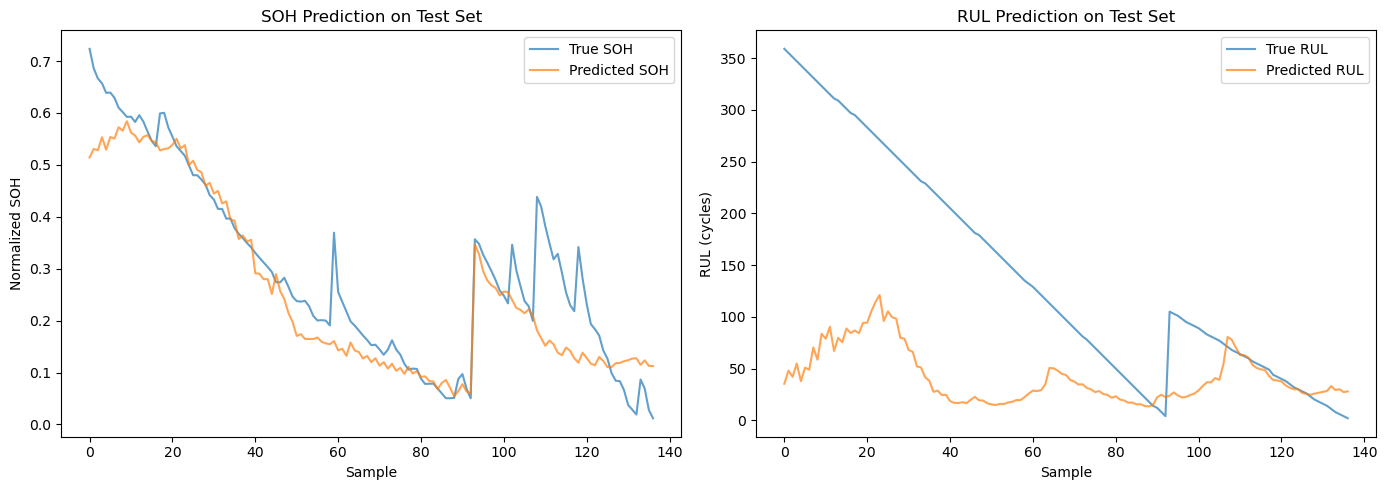

In [86]:
# ---------------------------- 6. 可视化 ----------------------------
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(soh_targets, label='True SOH', alpha=0.7)
plt.plot(soh_preds, label='Predicted SOH', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Normalized SOH')
plt.title('SOH Prediction on Test Set')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rul_targets_original, label='True RUL', alpha=0.7)
plt.plot(rul_preds_original, label='Predicted RUL', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('RUL (cycles)')
plt.title('RUL Prediction on Test Set')
plt.legend()

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150)
plt.show()